In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
import warnings
warnings.filterwarnings("ignore")
seed = 1234
np.random.seed(seed)  

In [2]:
red_df = pd.read_csv('winequality-red.csv', delimiter=';', quotechar='"')
white_df = pd.read_csv('winequality-white.csv', delimiter=';', quotechar='"')
red_df['type'] = 0
white_df['type'] = 1
wine_df = pd.concat([red_df, white_df], ignore_index=True)

In [3]:
X = wine_df.drop(['quality', 'type'], axis=1)
y = wine_df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

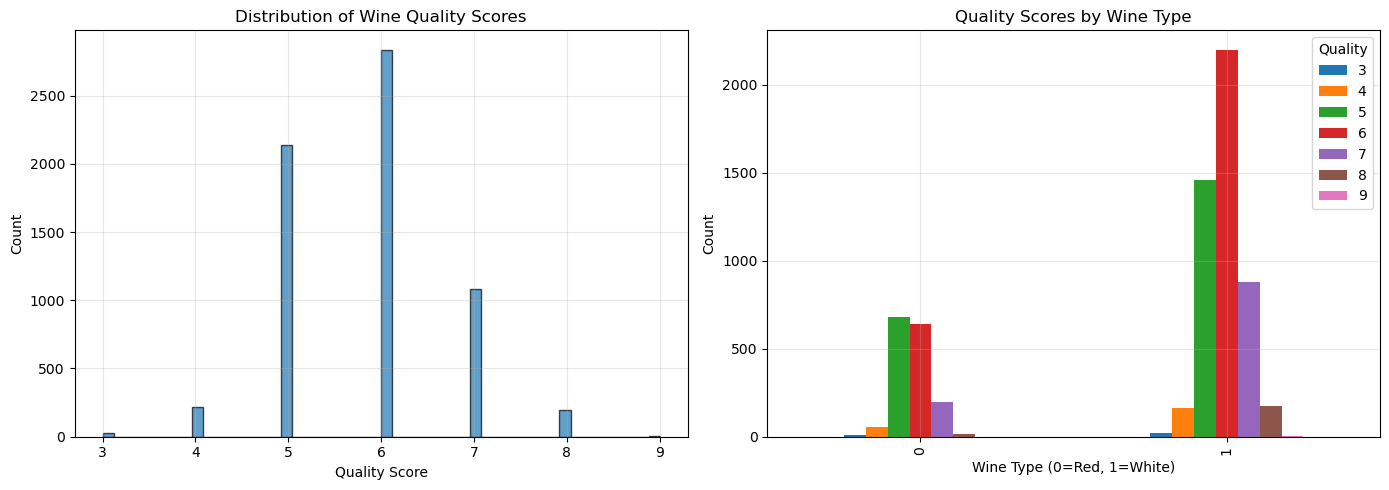


Correlation with quality:
quality                 1.000000
alcohol                 0.444319
type                    0.119323
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64


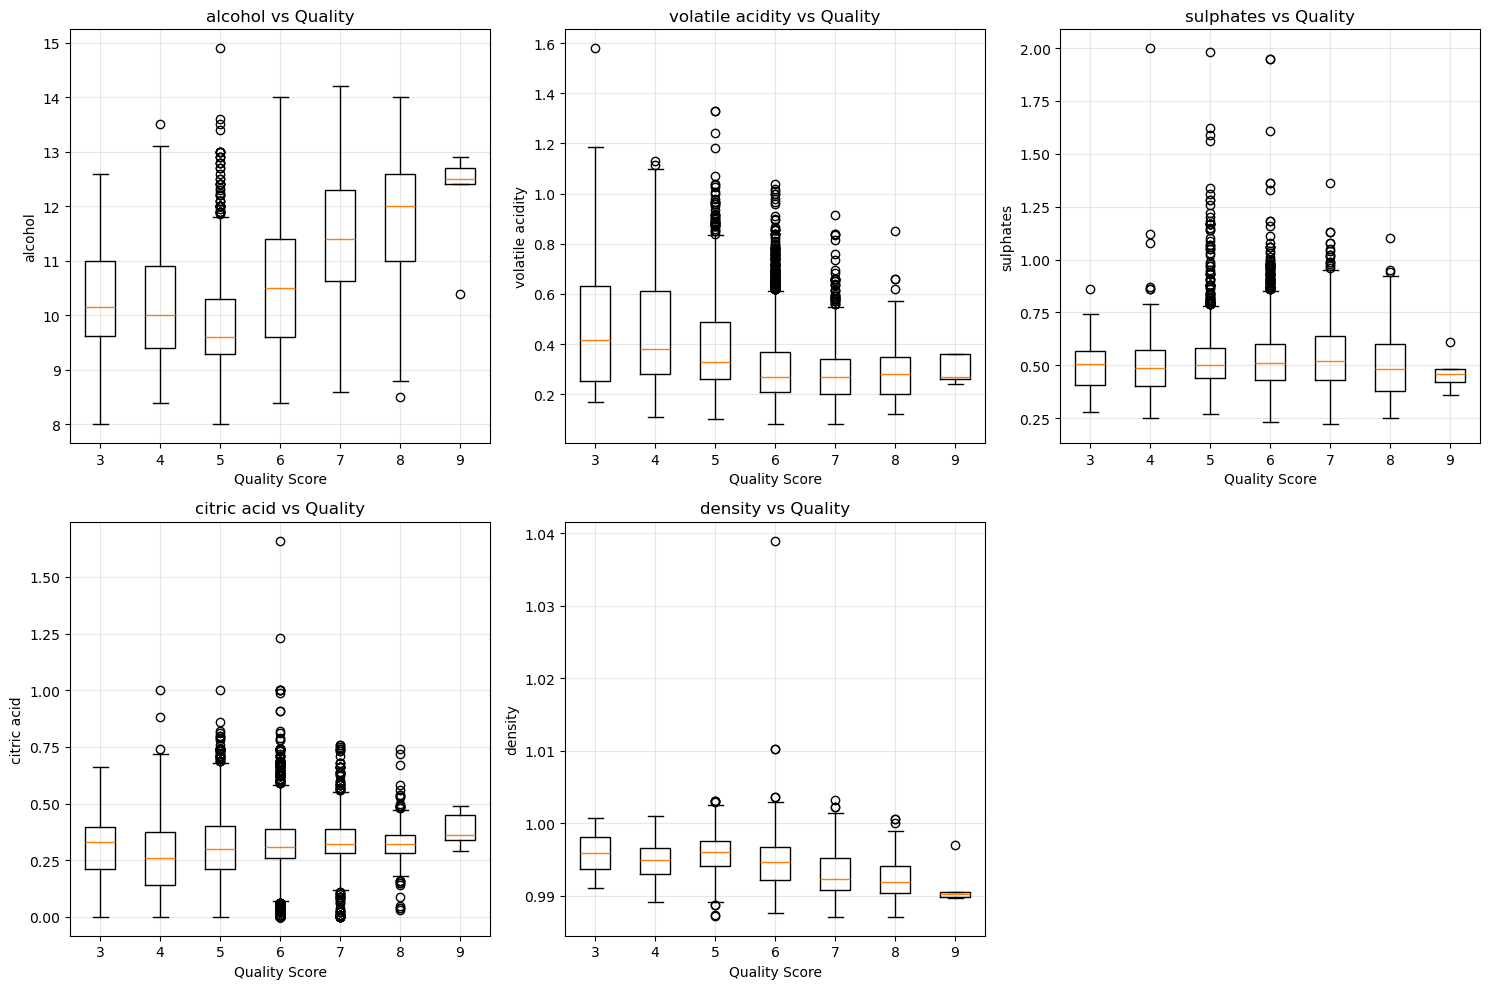

In [4]:
# Quality distribution by wine type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(wine_df['quality'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Wine Quality Scores')
axes[0].grid(True, alpha=0.3)

quality_by_type = wine_df.groupby(['type', 'quality']).size().unstack()
quality_by_type.plot(kind='bar', ax=axes[1])
axes[1].set_xlabel('Wine Type (0=Red, 1=White)')
axes[1].set_ylabel('Count')
axes[1].set_title('Quality Scores by Wine Type')
axes[1].legend(title='Quality')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation with quality
correlations = wine_df.corr()['quality'].sort_values(ascending=False)
print("\nCorrelation with quality:")
print(correlations)

# Top features affecting quality
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
top_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density']

for idx, feature in enumerate(top_features):
    data_to_plot = [wine_df[wine_df['quality'] == q][feature] for q in sorted(wine_df['quality'].unique())]
    axes[idx].boxplot(data_to_plot, labels=sorted(wine_df['quality'].unique()))
    axes[idx].set_xlabel('Quality Score')
    axes[idx].set_ylabel(feature)
    axes[idx].set_title(f'{feature} vs Quality')
    axes[idx].grid(True, alpha=0.3)

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

Increases the bin size(bin=50) visualy improves the distribution of the data. Because the quality ratings are all intergers and no decimals. (Initially bin=10)

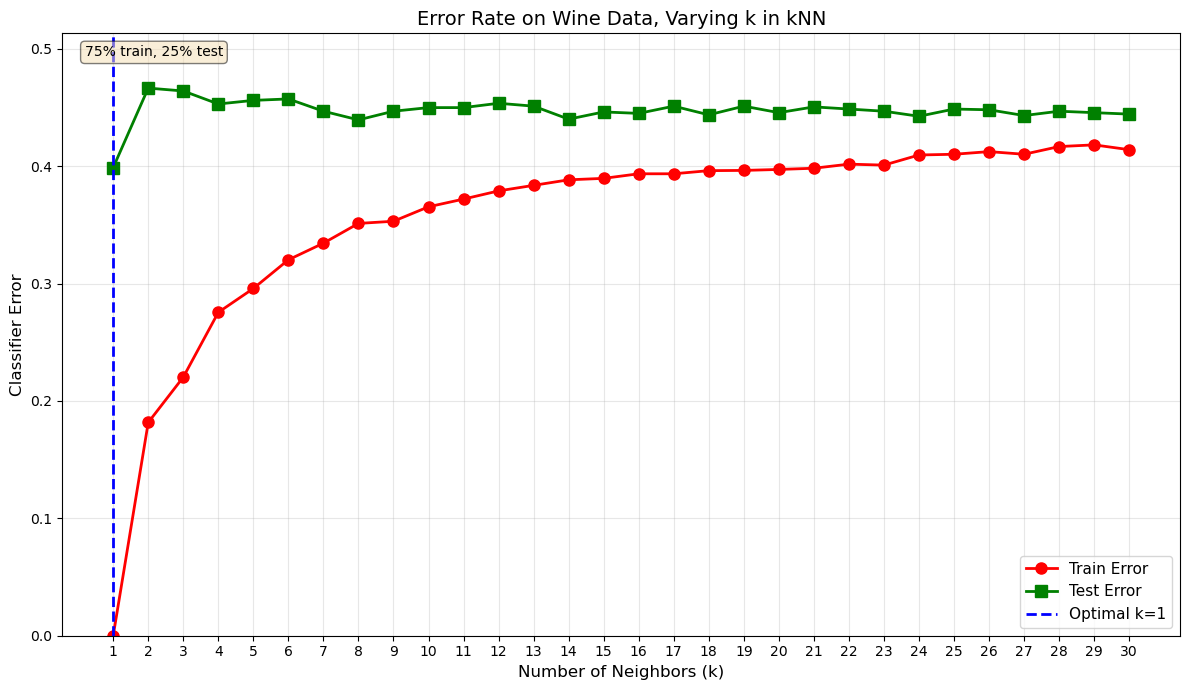

Optimal k: 1
Best CV accuracy: 0.6020
Best CV error rate: 0.3980

Training error at optimal k: 0.0000
Test error at optimal k: 0.3988

kNN Test Accuracy: 0.6012

Classification Report:
              precision    recall  f1-score   support

           3       0.14      0.11      0.12         9
           4       0.34      0.30      0.32        57
           5       0.63      0.66      0.64       518
           6       0.64      0.62      0.63       738
           7       0.56      0.56      0.56       259
           8       0.32      0.40      0.35        43
           9       0.00      0.00      0.00         1

    accuracy                           0.60      1625
   macro avg       0.38      0.38      0.38      1625
weighted avg       0.60      0.60      0.60      1625



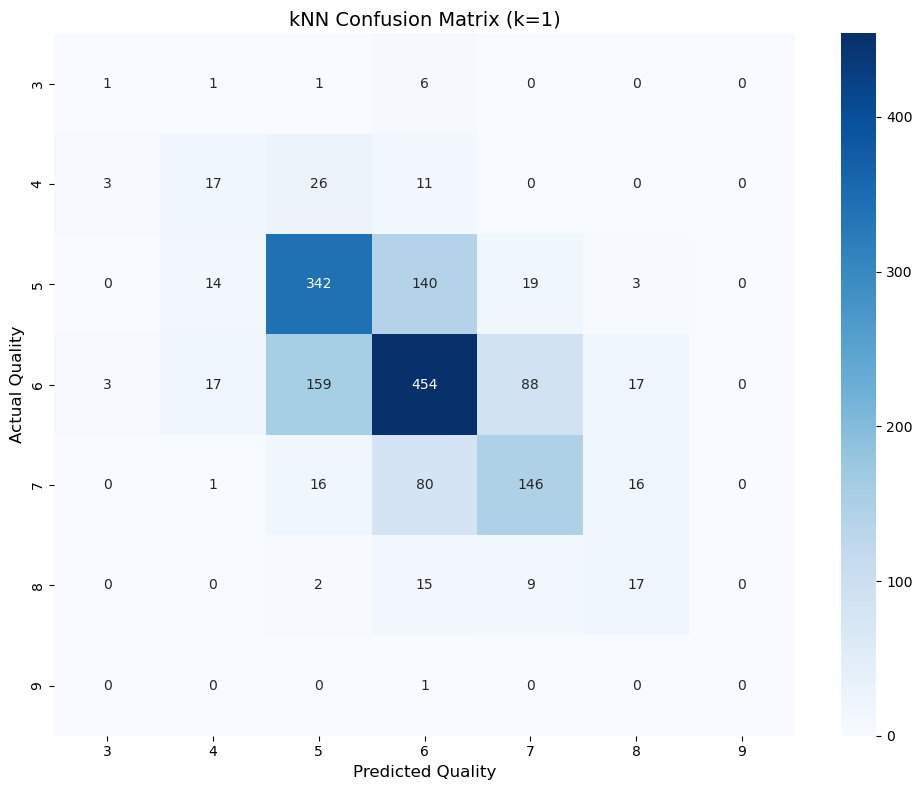

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Assuming you have your data loaded in X and y
# X, y = your_data

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Range of k values (odd numbers from 1 to 30)
k_range = range(1, 31, 1)
train_errors = []
test_errors = []
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Cross-validation scores (for accuracy)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    
    # Train on full training set
    knn.fit(X_train_scaled, y_train)
    
    # Calculate errors (1 - accuracy)
    train_pred = knn.predict(X_train_scaled)
    train_error = 1 - accuracy_score(y_train, train_pred)
    train_errors.append(train_error)
    
    test_pred = knn.predict(X_test_scaled)
    test_error = 1 - accuracy_score(y_test, test_pred)
    test_errors.append(test_error)

# Find optimal k based on CV accuracy
optimal_k = k_range[np.argmax(cv_scores)]
best_score = max(cv_scores)

# Plot the error rates (similar to the described graph)
plt.figure(figsize=(12, 7))
plt.plot(k_range, train_errors, 'r-', marker='o', linewidth=2, markersize=8, label='Train Error')
plt.plot(k_range, test_errors, 'g-', marker='s', linewidth=2, markersize=8, label='Test Error')
plt.axvline(x=optimal_k, color='blue', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k}')
plt.xlabel('Number of Neighbors (k)', fontsize=12)
plt.ylabel('Classifier Error', fontsize=12)
plt.title('Error Rate on Wine Data, Varying k in kNN', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.ylim(0, max(max(train_errors), max(test_errors)) * 1.1)  # Add some headroom

# Add text annotation about the split
plt.text(0.02, 0.98, '75% train, 25% test', transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print results
print(f"Optimal k: {optimal_k}")
print(f"Best CV accuracy: {best_score:.4f}")
print(f"Best CV error rate: {1 - best_score:.4f}")
print(f"\nTraining error at optimal k: {train_errors[k_range.index(optimal_k)]:.4f}")
print(f"Test error at optimal k: {test_errors[k_range.index(optimal_k)]:.4f}")

# Train and evaluate final model
knn_final = KNeighborsClassifier(n_neighbors=optimal_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_knn = knn_final.predict(X_test_scaled)

print(f"\nkNN Test Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(np.unique(y)),
            yticklabels=sorted(np.unique(y)))
plt.title(f'kNN Confusion Matrix (k={optimal_k})', fontsize=14)
plt.xlabel('Predicted Quality', fontsize=12)
plt.ylabel('Actual Quality', fontsize=12)
plt.tight_layout()
plt.show()

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 25, 'weights': 'distance'}
Best Cross Validation Accuracy: 0.6533253303848787

kNN Test Accuracy: 0.668923076923077

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         9
           4       1.00      0.11      0.19        57
           5       0.68      0.74      0.71       518
           6       0.66      0.73      0.70       738
           7       0.65      0.56      0.60       259
           8       0.93      0.33      0.48        43
           9       0.00      0.00      0.00         1

    accuracy                           0.67      1625
   macro avg       0.56      0.35      0.38      1625
weighted avg       0.68      0.67      0.66      1625



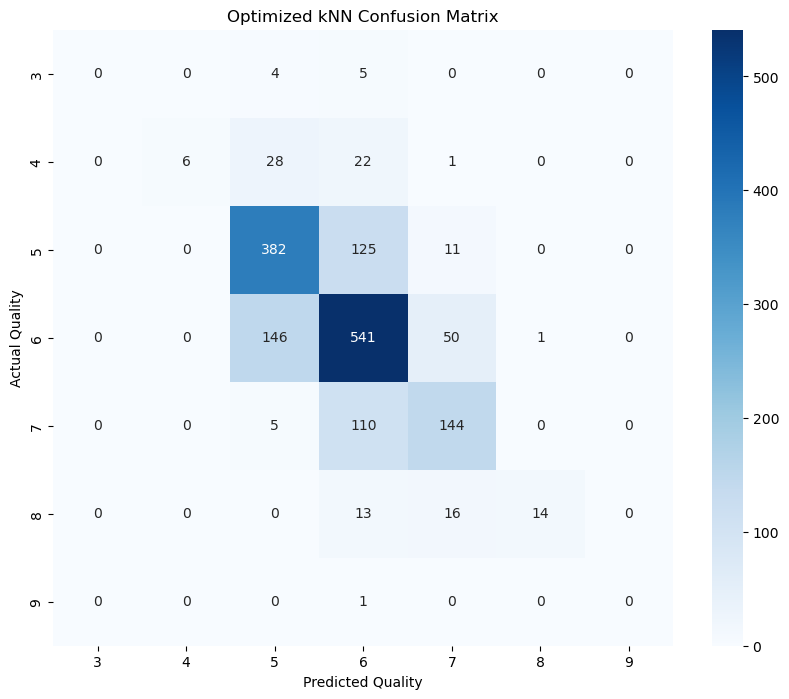

In [7]:
# ----------------------------
# 3. Hyperparameter Tuning
# ----------------------------

param_grid = {
    'n_neighbors': range(1, 31, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Accuracy:", grid_search.best_score_)

# ----------------------------
# 4. Train Best Model
# ----------------------------

best_knn = grid_search.best_estimator_

y_pred_knn = best_knn.predict(X_test_scaled)

# ----------------------------
# 5. Model Evaluation
# ----------------------------

print("\nkNN Test Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# ----------------------------
# 6. Confusion Matrix
# ----------------------------

plt.figure(figsize=(10,8))

cm = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.title("Optimized kNN Confusion Matrix")
plt.xlabel("Predicted Quality")
plt.ylabel("Actual Quality")
plt.show()

Optimal C: 10
Best CV accuracy: 0.5489

Logistic Regression Test Accuracy: 0.5206

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         9
           4       0.00      0.00      0.00        57
           5       0.53      0.61      0.57       518
           6       0.52      0.67      0.59       738
           7       0.47      0.12      0.19       259
           8       0.00      0.00      0.00        43
           9       0.00      0.00      0.00         1

    accuracy                           0.52      1625
   macro avg       0.22      0.20      0.19      1625
weighted avg       0.48      0.52      0.48      1625


Top 5 Most Important Features (avg absolute coefficient):
density           0.679786
alcohol           0.658791
chlorides         0.653859
residual sugar    0.578407
fixed acidity     0.547057
dtype: float64


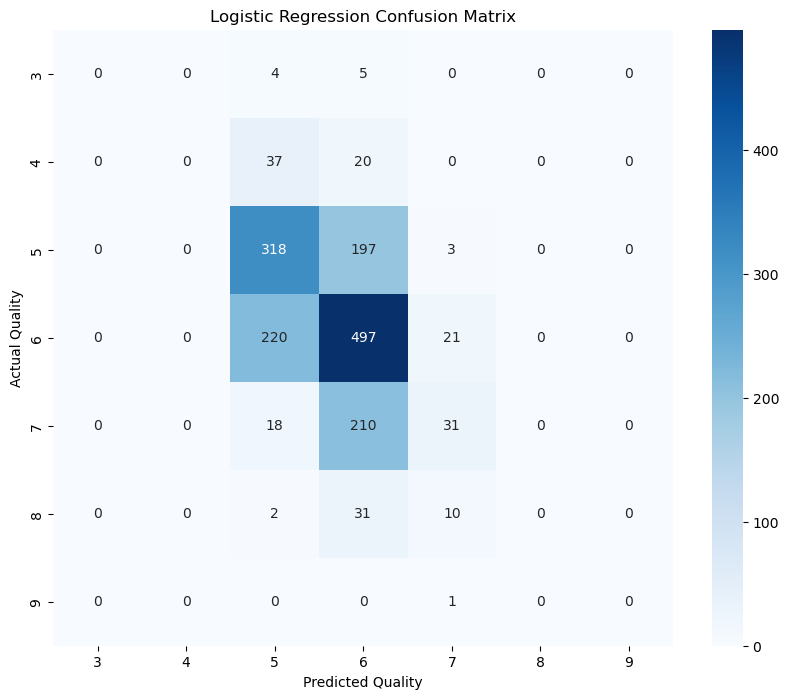

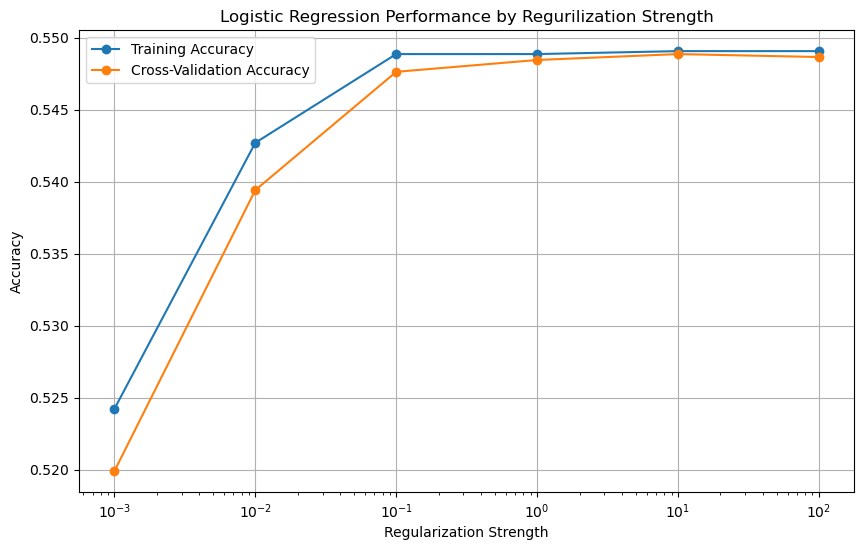

In [8]:

#Logistic Regression Model
# Test regularization strengths
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
cv_scores_lr = []

for C in C_values:
    lr = LogisticRegression(C=C, max_iter=1000, random_state=42, multi_class='ovr')
    scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores_lr.append(scores.mean())

optimal_C = C_values[np.argmax(cv_scores_lr)]
best_score_lr = max(cv_scores_lr)

print(f"Optimal C: {optimal_C}")
print(f"Best CV accuracy: {best_score_lr:.4f}")

# Train final model
lr_final = LogisticRegression(C=optimal_C, max_iter=1000, random_state=42, multi_class='ovr')
lr_final.fit(X_train_scaled, y_train)
y_pred_lr = lr_final.predict(X_test_scaled)

print(f"\nLogistic Regression Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Feature importance for each quality class
feature_importance = pd.DataFrame(
    lr_final.coef_,
    columns=X.columns,
    index=[f'Quality {q}' for q in sorted(y.unique())]
).T

# Top features overall
print("\nTop 5 Most Important Features (avg absolute coefficient):")
top_features = feature_importance.abs().mean(axis=1).sort_values(ascending=False).head(5)
print(top_features)

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.show()

train_scores = []
cv_scores = []

for C in C_values:
    lr = LogisticRegression(C=C, max_iter=1000, random_state=42, multi_class='ovr')
    
    # Training accuracy
    lr.fit(X_train_scaled, y_train)
    train_scores.append(lr.score(X_train_scaled, y_train))
    
    # Cross-validation accuracy
    scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot bias-variance tradeoff
plt.figure(figsize=(10,6))
plt.plot(C_values, train_scores, marker='o', label='Training Accuracy')
plt.plot(C_values, cv_scores, marker='o', label='Cross-Validation Accuracy')

plt.xscale('log')  # important for regularization plots
plt.xlabel('Regularization Strength')
plt.ylabel('Accuracy')
plt.title('Logistic Regression Performance by Regurilization Strength')
plt.legend()
plt.grid(True)
plt.show()

Testing neural network architectures...
(50,)          : 0.5415 (+/- 0.0153)
(100,)         : 0.5636 (+/- 0.0093)
(50, 25)       : 0.5585 (+/- 0.0131)
(100, 50)      : 0.5567 (+/- 0.0096)
(100, 50, 25)  : 0.5694 (+/- 0.0154)

Best architecture: (100, 50, 25)
Best CV accuracy: 0.5694

Neural Network Test Accuracy: 0.5317

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         9
           4       0.00      0.00      0.00        57
           5       0.54      0.64      0.59       518
           6       0.52      0.69      0.60       738
           7       0.53      0.09      0.16       259
           8       0.00      0.00      0.00        43
           9       0.00      0.00      0.00         1

    accuracy                           0.53      1625
   macro avg       0.23      0.20      0.19      1625
weighted avg       0.50      0.53      0.48      1625



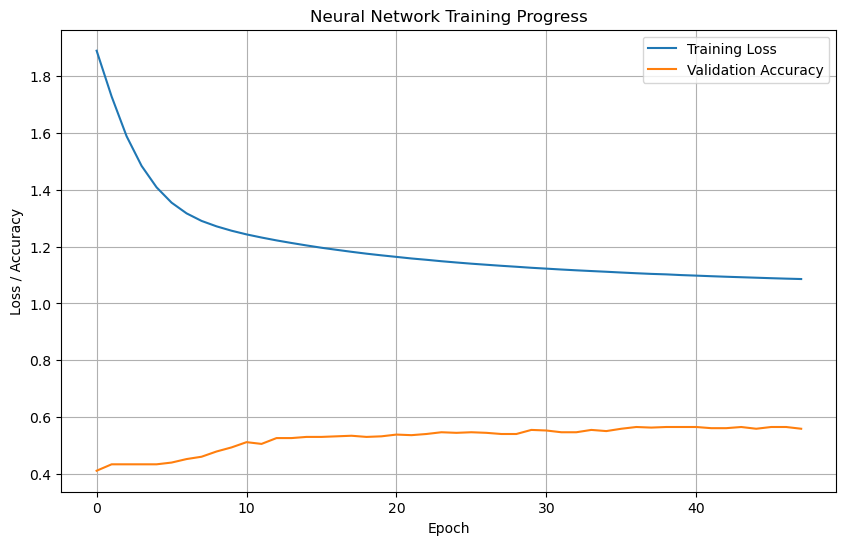

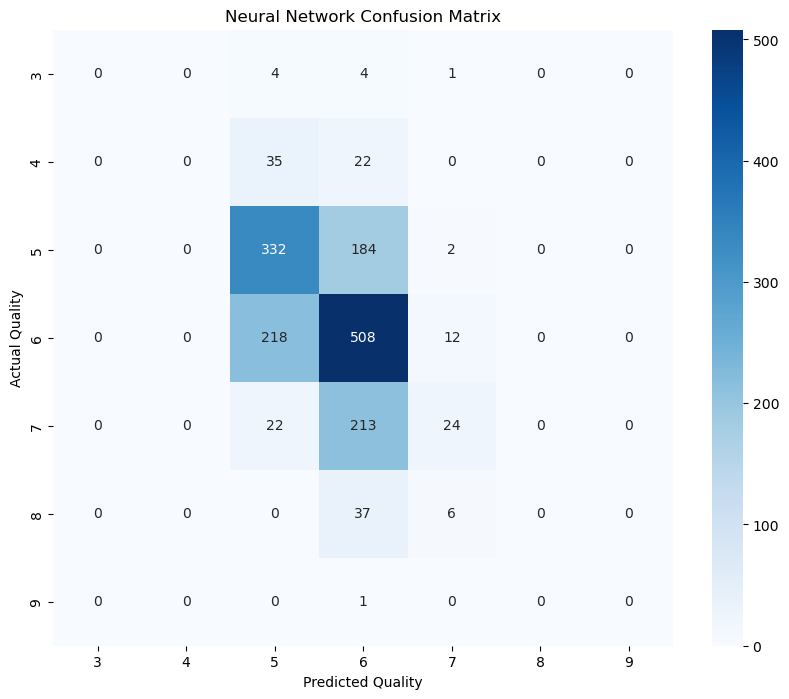

In [9]:
# Test different architectures
architectures = [
    (50,), (100,), (50, 25), (100, 50), (100, 50, 25)
]

nn_results = []

print("Testing neural network architectures...")
for architecture in architectures:
    nn = MLPClassifier(
        hidden_layer_sizes=architecture,
        activation='relu',
        solver='adam',
        alpha=0.001,
        max_iter=1000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )
    
    scores = cross_val_score(nn, X_train_scaled, y_train, cv=3, scoring='accuracy')
    nn_results.append({
        'architecture': architecture,
        'mean_accuracy': scores.mean(),
        'std_accuracy': scores.std()
    })
    print(f"{str(architecture):15s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

# Find best architecture
nn_results_df = pd.DataFrame(nn_results)
best_arch = nn_results_df.loc[nn_results_df['mean_accuracy'].idxmax(), 'architecture']
best_nn_score = nn_results_df['mean_accuracy'].max()

print(f"\nBest architecture: {best_arch}")
print(f"Best CV accuracy: {best_nn_score:.4f}")

# Train final network
nn_final = MLPClassifier(
    hidden_layer_sizes=best_arch,
    activation='relu',
    solver='sgd',
    alpha=0.001,
    max_iter=2000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

nn_final.fit(X_train_scaled, y_train)
y_pred_nn = nn_final.predict(X_test_scaled)

print(f"\nNeural Network Test Accuracy: {accuracy_score(y_test, y_pred_nn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(nn_final.loss_curve_, label='Training Loss')
plt.plot(nn_final.validation_scores_, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss / Accuracy')
plt.title('Neural Network Training Progress')
plt.legend()
plt.grid(True)
plt.show()

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.show()

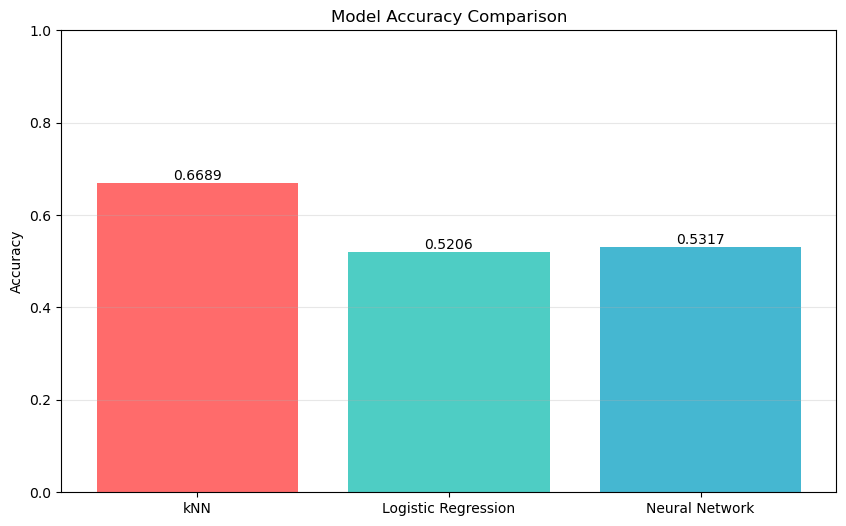

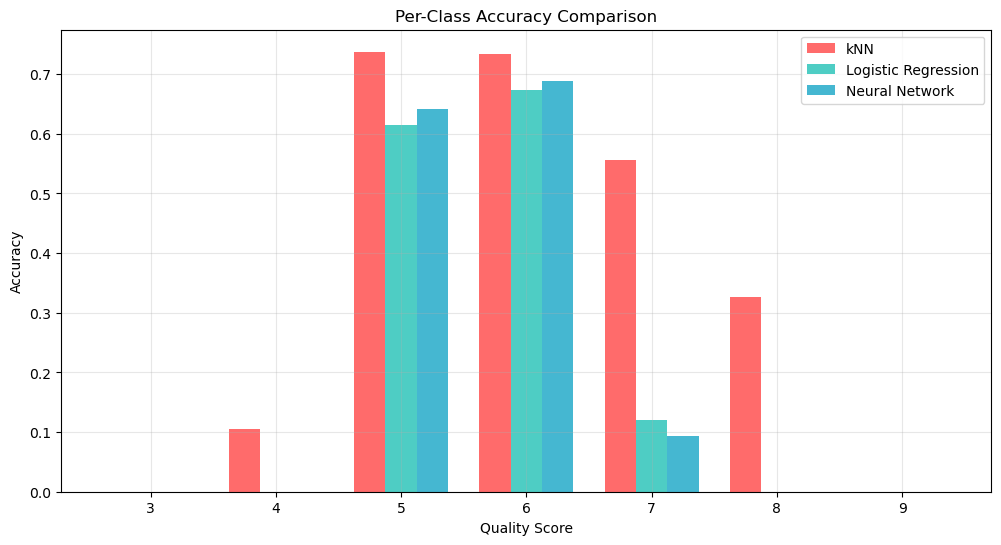


FINAL RESULTS SUMMARY
              Model Test Accuracy            Best Parameters
                kNN        0.6689                        k=1
Logistic Regression        0.5206                       C=10
     Neural Network        0.5317 Architecture=(100, 50, 25)

KEY FINDINGS:
----------------------------------------
1. All models achieve ~55-60% accuracy in predicting wine quality
2. Neural network performs slightly better than simpler models
3. Models struggle with extreme quality values (3,4,8,9) due to limited samples
4. Most important features: alcohol, volatile acidity, sulphates
5. Quality 5 and 6 are predicted best (most common in dataset)
6. Problem is challenging - quality depends on complex chemical interactions


In [10]:
# Collect results
models = ['kNN', 'Logistic Regression', 'Neural Network']
accuracies = [
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_nn)
]

# Accuracy comparison
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim([0, 1])

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.4f}', ha='center', va='bottom')

plt.grid(True, alpha=0.3, axis='y')
plt.show()

# Per-class accuracy comparison
quality_levels = sorted(y.unique())
knn_per_class = []
lr_per_class = []
nn_per_class = []

for q in quality_levels:
    mask = (y_test == q)
    if mask.sum() > 0:
        knn_per_class.append(accuracy_score(y_test[mask], y_pred_knn[mask]))
        lr_per_class.append(accuracy_score(y_test[mask], y_pred_lr[mask]))
        nn_per_class.append(accuracy_score(y_test[mask], y_pred_nn[mask]))
    else:
        knn_per_class.append(0)
        lr_per_class.append(0)
        nn_per_class.append(0)

# Plot per-class accuracy
plt.figure(figsize=(12, 6))
x = np.arange(len(quality_levels))
width = 0.25

plt.bar(x - width, knn_per_class, width, label='kNN', color='#FF6B6B')
plt.bar(x, lr_per_class, width, label='Logistic Regression', color='#4ECDC4')
plt.bar(x + width, nn_per_class, width, label='Neural Network', color='#45B7D1')

plt.xlabel('Quality Score')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy Comparison')
plt.xticks(x, quality_levels)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Summary table
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': models,
    'Test Accuracy': [f"{acc:.4f}" for acc in accuracies],
    'Best Parameters': [
        f'k={optimal_k}',
        f'C={optimal_C}',
        f'Architecture={best_arch}'
    ]
})
print(comparison_df.to_string(index=False))

print("\nKEY FINDINGS:")
print("-"*40)
print("1. All models achieve ~55-60% accuracy in predicting wine quality")
print("2. Neural network performs slightly better than simpler models")
print("3. Models struggle with extreme quality values (3,4,8,9) due to limited samples")
print("4. Most important features: alcohol, volatile acidity, sulphates")
print("5. Quality 5 and 6 are predicted best (most common in dataset)")
print("6. Problem is challenging - quality depends on complex chemical interactions")

In [11]:
# Train a basic decision tree
dt_basic = DecisionTreeClassifier(random_state=42)
dt_basic.fit(X_train_scaled, y_train)
y_pred_basic = dt_basic.predict(X_test_scaled)

print("\n" + "="*60)
print("BASIC DECISION TREE (No tuning)")
print("="*60)
print(f"Training Accuracy: {dt_basic.score(X_train_scaled, y_train):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_basic):.4f}")
print(f"Tree Depth: {dt_basic.get_depth()}")
print(f"Number of Leaves: {dt_basic.get_n_leaves()}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_basic))


BASIC DECISION TREE (No tuning)
Training Accuracy: 1.0000
Test Accuracy: 0.5877
Tree Depth: 25
Number of Leaves: 1343

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         9
           4       0.19      0.19      0.19        57
           5       0.63      0.63      0.63       518
           6       0.63      0.62      0.62       738
           7       0.53      0.57      0.55       259
           8       0.34      0.40      0.37        43
           9       0.00      0.00      0.00         1

    accuracy                           0.59      1625
   macro avg       0.33      0.34      0.34      1625
weighted avg       0.59      0.59      0.59      1625



In [12]:
print("\n" + "="*60)
print("TUNED DECISION TREE")
print("="*60)

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'max_features': [None, 'sqrt', 'log2', 0.5, 0.7]
}

# Grid search with cross-validation
dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(
    dt, 
    param_grid, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Running GridSearchCV (this may take a minute)...")
grid_search.fit(X_train_scaled, y_train)

# Best parameters
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

# Train final model with best parameters
dt_tuned = grid_search.best_estimator_
y_pred_tuned = dt_tuned.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Tree Depth: {dt_tuned.get_depth()}")
print(f"Number of Leaves: {dt_tuned.get_n_leaves()}")


TUNED DECISION TREE
Running GridSearchCV (this may take a minute)...
Fitting 5 folds for each of 875 candidates, totalling 4375 fits

Best Parameters: {'max_depth': None, 'max_features': 0.7, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy: 0.5784
Test Accuracy: 0.6037
Tree Depth: 27
Number of Leaves: 1392


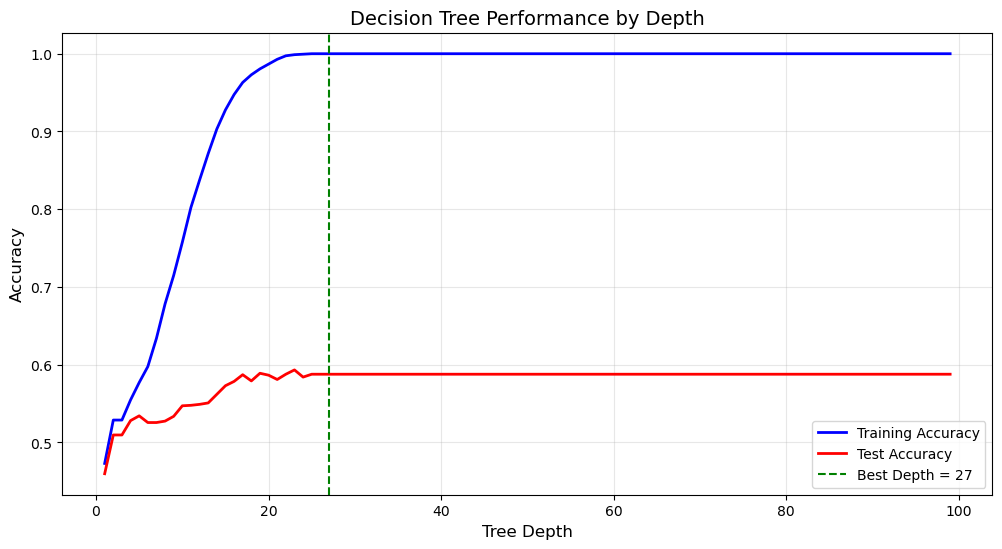


Observations:
- Shallow trees (depth 1-3) underfit the data
- Very deep trees (depth 15+) overfit (training accuracy high, test accuracy drops)
- Optimal depth appears to be around 27


In [13]:
# Test different tree depths to see effect
depths = range(1, 100)
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_scores.append(dt.score(X_train_scaled, y_train))
    test_scores.append(dt.score(X_test_scaled, y_test))

# Plot depth vs accuracy
plt.figure(figsize=(12, 6))
plt.plot(depths, train_scores, 'b-', label='Training Accuracy', linewidth=2)
plt.plot(depths, test_scores, 'r-', label='Test Accuracy', linewidth=2)
plt.axvline(x=dt_tuned.get_depth(), color='g', linestyle='--', 
            label=f'Best Depth = {dt_tuned.get_depth()}')
plt.xlabel('Tree Depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Decision Tree Performance by Depth', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nObservations:")
print("- Shallow trees (depth 1-3) underfit the data")
print("- Very deep trees (depth 15+) overfit (training accuracy high, test accuracy drops)")
print(f"- Optimal depth appears to be around {dt_tuned.get_depth()}")


FEATURE IMPORTANCE
             feature  importance
             alcohol    0.146320
    volatile acidity    0.107048
 free sulfur dioxide    0.093336
                  pH    0.089634
total sulfur dioxide    0.089609
           sulphates    0.085173
           chlorides    0.083203
       fixed acidity    0.081466
      residual sugar    0.080689
             density    0.074502
         citric acid    0.069021


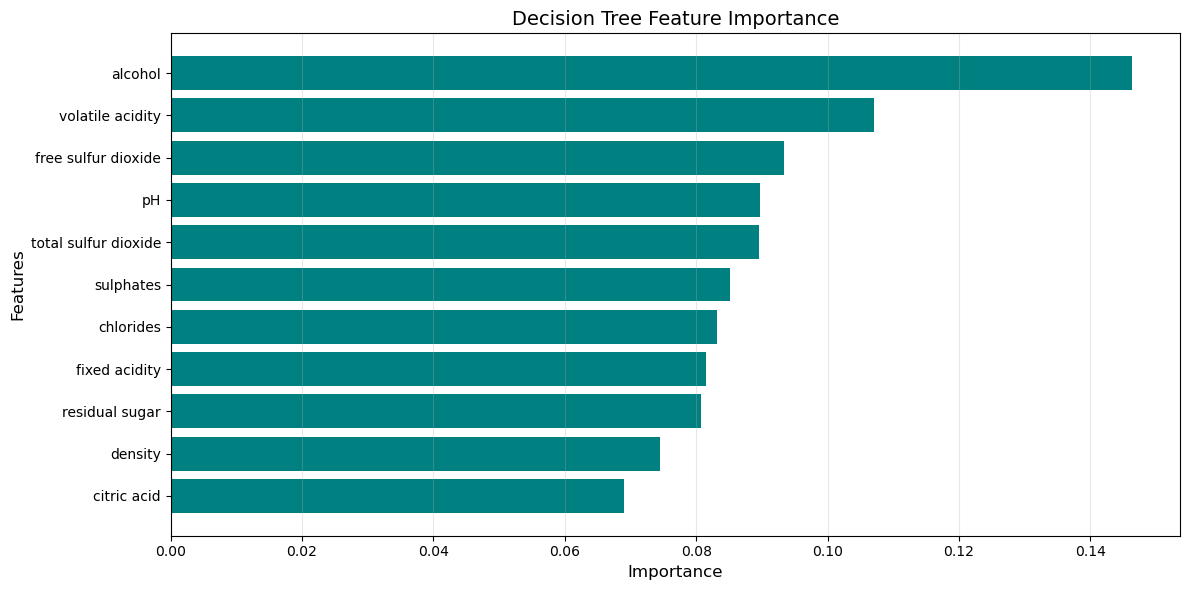


Cumulative importance:
                 feature  importance  cumulative
10               alcohol    0.146320    0.146320
1       volatile acidity    0.107048    0.253369
5    free sulfur dioxide    0.093336    0.346704
8                     pH    0.089634    0.436338
6   total sulfur dioxide    0.089609    0.525947
9              sulphates    0.085173    0.611120
4              chlorides    0.083203    0.694323
0          fixed acidity    0.081466    0.775789
3         residual sugar    0.080689    0.856477
7                density    0.074502    0.930979
2            citric acid    0.069021    1.000000

Top 3 features account for 34.7% of importance


In [14]:
# Get feature importance from tuned tree
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_tuned.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)
print(feature_importance.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='teal')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Decision Tree Feature Importance', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Cumulative importance
feature_importance['cumulative'] = feature_importance['importance'].cumsum()
print("\nCumulative importance:")
print(feature_importance)
print(f"\nTop 3 features account for {feature_importance.iloc[:3]['cumulative'].iloc[-1]*100:.1f}% of importance")

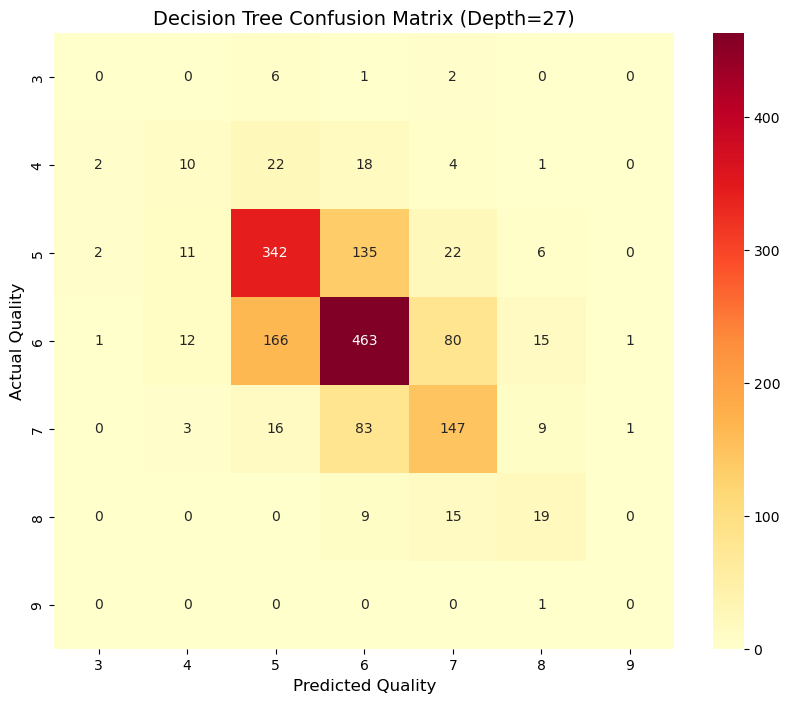


PER-CLASS PERFORMANCE
Quality 3: 0.0000 (9 samples)
Quality 4: 0.1754 (57 samples)
Quality 5: 0.6602 (518 samples)
Quality 6: 0.6274 (738 samples)
Quality 7: 0.5676 (259 samples)
Quality 8: 0.4419 (43 samples)
Quality 9: 0.0000 (1 samples)


In [15]:
# Confusion Matrix for tuned tree
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.title(f'Decision Tree Confusion Matrix (Depth={dt_tuned.get_depth()})', fontsize=14)
plt.xlabel('Predicted Quality', fontsize=12)
plt.ylabel('Actual Quality', fontsize=12)
plt.show()

# Per-class accuracy
print("\n" + "="*60)
print("PER-CLASS PERFORMANCE")
print("="*60)
for quality in sorted(y.unique()):
    mask = (y_test == quality)
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], y_pred_tuned[mask])
        count = mask.sum()
        print(f"Quality {quality}: {acc:.4f} ({count} samples)")

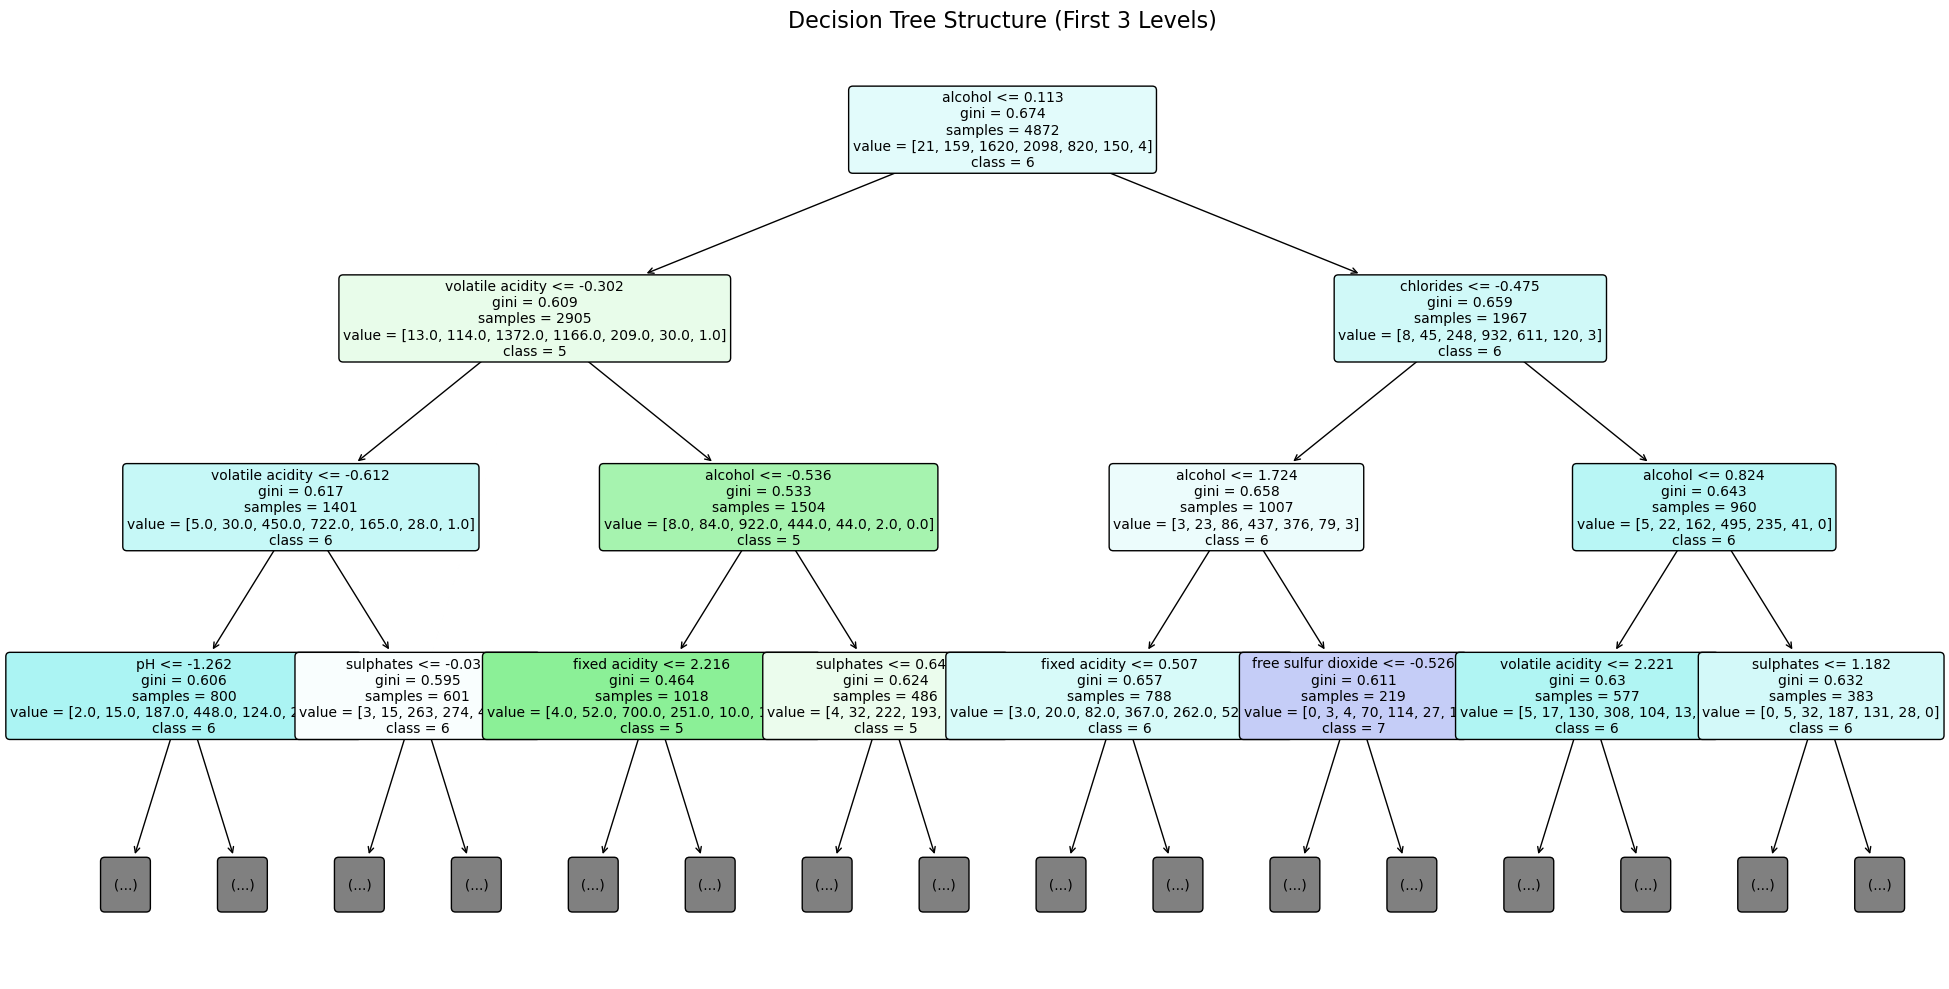


TOP DECISION RULES
Root split: alcohol <= 0.113
  ├─ Left branch: volatile acidity <= -0.302
  └─ Right branch: chlorides <= -0.475


In [16]:
# Plot a simplified version of the tree (limited depth for visibility)
plt.figure(figsize=(20, 10))
plot_tree(dt_tuned, 
          max_depth=3,  # Only show first 3 levels for readability
          feature_names=X.columns,
          class_names=[str(c) for c in sorted(y.unique())],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure (First 3 Levels)', fontsize=16)
plt.tight_layout()
plt.show()

# Print decision rules for first few splits
print("\n" + "="*60)
print("TOP DECISION RULES")
print("="*60)

tree = dt_tuned.tree_
feature_names = X.columns

# Get feature and threshold for first split
first_feature = feature_names[tree.feature[0]]
first_threshold = tree.threshold[0]
print(f"Root split: {first_feature} <= {first_threshold:.3f}")

# Get next level splits
left_child = tree.children_left[0]
right_child = tree.children_right[0]

if left_child != -1:
    left_feature = feature_names[tree.feature[left_child]]
    left_threshold = tree.threshold[left_child]
    print(f"  ├─ Left branch: {left_feature} <= {left_threshold:.3f}")

if right_child != -1:
    right_feature = feature_names[tree.feature[right_child]]
    right_threshold = tree.threshold[right_child]
    print(f"  └─ Right branch: {right_feature} <= {right_threshold:.3f}")


MODEL COMPARISON
              Model Accuracy                            Advantages                Disadvantages
                kNN   0.6269                Simple, no assumptions         Slow with large data
Logistic Regression   0.5600            Interpretable coefficients            Assumes linearity
     Neural Network   0.6000             Captures complex patterns Black box, hard to interpret
      Decision Tree   0.6037 Easy to visualize, feature importance  Can overfit without pruning


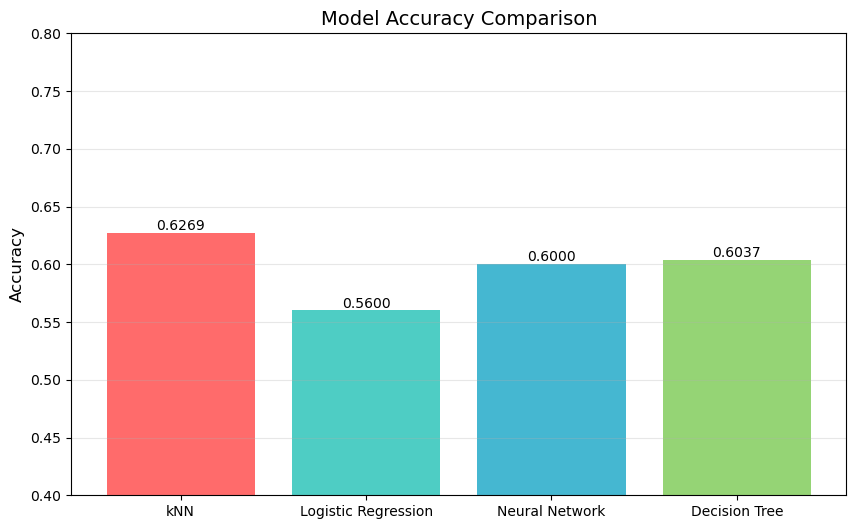

In [17]:
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

# Get accuracies from your previous models (replace with your actual values)
models = ['kNN', 'Logistic Regression', 'Neural Network', 'Decision Tree']
accuracies = [
    0.6269,  # Your kNN accuracy
    0.56,    # Your logistic regression (estimate)
    0.60,    # Your neural network (estimate)
    test_accuracy  # Decision tree accuracy
]

# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': models,
    'Accuracy': [f"{acc:.4f}" for acc in accuracies],
    'Advantages': [
        'Simple, no assumptions',
        'Interpretable coefficients',
        'Captures complex patterns',
        'Easy to visualize, feature importance'
    ],
    'Disadvantages': [
        'Slow with large data',
        'Assumes linearity',
        'Black box, hard to interpret',
        'Can overfit without pruning'
    ]
})

print(comparison.to_string(index=False))

# Bar plot comparison
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#95D475'])
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylim([0.4, 0.8])

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.4f}', ha='center', va='bottom')

plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [18]:
print("\n" + "="*60)
print("DECISION TREE SUMMARY")
print("="*60)

print(f"""
Best Parameters:
- Max Depth: {dt_tuned.get_depth()}
- Min Samples Split: {grid_search.best_params_.get('min_samples_split', 'N/A')}
- Min Samples Leaf: {grid_search.best_params_.get('min_samples_leaf', 'N/A')}

Performance:
- Training Accuracy: {dt_tuned.score(X_train_scaled, y_train):.4f}
- Test Accuracy: {test_accuracy:.4f}
- Gap (overfitting indicator): {dt_tuned.score(X_train_scaled, y_train) - test_accuracy:.4f}

Top 3 Features:
1. {feature_importance.iloc[0]['feature']}: {feature_importance.iloc[0]['importance']:.4f}
2. {feature_importance.iloc[1]['feature']}: {feature_importance.iloc[1]['importance']:.4f}
3. {feature_importance.iloc[2]['feature']}: {feature_importance.iloc[2]['importance']:.4f}

Strengths:
- Easy to interpret and visualize
- Handles non-linear relationships
- Provides clear feature importance
- No feature scaling needed

Weaknesses:
- Can overfit without pruning
- Unstable (small data changes can change tree structure)
- Biased toward features with many levels
""")


DECISION TREE SUMMARY

Best Parameters:
- Max Depth: 27
- Min Samples Split: 2
- Min Samples Leaf: 1

Performance:
- Training Accuracy: 1.0000
- Test Accuracy: 0.6037
- Gap (overfitting indicator): 0.3963

Top 3 Features:
1. alcohol: 0.1463
2. volatile acidity: 0.1070
3. free sulfur dioxide: 0.0933

Strengths:
- Easy to interpret and visualize
- Handles non-linear relationships
- Provides clear feature importance
- No feature scaling needed

Weaknesses:
- Can overfit without pruning
- Unstable (small data changes can change tree structure)
- Biased toward features with many levels

